# Phase 1 - Tracking backbone (detection + track IDs) on `dance.mp4`

**Goal.** Produce an MP4 with bounding boxes and *persistent per-person track IDs* from a
recorded video, offline. This is the identity backbone for the larger goal (decide which
person completes a described action-sequence first).

**Key finding that shaped this notebook.** The deployed `alerts` profile runs the CV
perception service (`vss-rtvi-cv`) in API mode: it waits for sources pushed over REST
(`/api/v1/stream/add`) and feeds them through `nvmultiurisrcbin`. On this box that path
**stalls** - the source opens then instantly EOSes with zero frames
(`Got data flow before segment event`, `Active sources: 0`). We proved decode itself is
fine (a plain `gst-launch` pipeline decodes 150/150 frames on both hardware and software
decoders), so the fault is in the `nvmultiurisrcbin`/new-streammux *source-add* path, not
the decoder or the file. That path is under review with NVIDIA.

**Approach used here (the bypass).** Run the stock `deepstream-app` binary with a **static**
file source and the classic streammux, reusing the profile's *own* RT-DETR detector +
NvDCF tracker + OSD. Same models, reliable source activation, tracked MP4 out.

Everything runs through `docker exec` into the `vss-rtvi-cv` container (which has DeepStream,
the models, and `ffmpeg`). The host Python here only needs the standard library + subprocess.

## Step 0 - Setup and prerequisite checks

We define paths and a small shell helper, then confirm the container is up and the assets
the pipeline depends on are present:

- `deepstream-app` binary,
- the RT-DETR ONNX/engine and its labels (`person` is class index 3),
- the cached NvDCF ReID engine (used by the *accuracy* tracker profile),
- the `x264enc` software encoder - **required on H100, which has no NVENC hardware**.

In [9]:
import os, subprocess, textwrap

CONTAINER    = 'vss-rtvi-cv'
REPO         = '/home/nvidia/Documents/video-search-and-summarization'
HOST_MODELS  = f'{REPO}/deploy/docker/data-dir/models'          # <-> container /opt/storage
HOST_CONFIGS = f'{REPO}/deploy/docker/developer-profiles/dev-profile-alerts/deepstream/configs'
APP_CFG_DIR  = '/opt/nvidia/deepstream/deepstream-9.1/sources/apps/sample_apps/metropolis_perception_app'
CFG_NAME     = 'ds_track_bypass.txt'
RAW_SRC      = os.path.expanduser('~/Documents/video/celtic_dance.mp4')
FINAL_OUT    = os.path.expanduser('~/Documents/video_tracked/celtic_dance_tracked_alerts.mp4')

def sh(cmd, timeout=None, show=True):
    if show: print('$', cmd)
    r = subprocess.run(cmd, shell=True, capture_output=True, text=True, timeout=timeout)
    if r.stdout.strip(): print(r.stdout.rstrip())
    if r.returncode != 0 and r.stderr.strip():
        print('  [stderr]', r.stderr.rstrip()[-2000:])
    return r

def dex(inner, timeout=None, show=True):
    """Run a command inside the container via bash -lc."""
    return sh(f"docker exec {CONTAINER} bash -lc {inner!r}", timeout=timeout, show=show)

print('container status:')
sh(f"docker ps --filter name={CONTAINER} --format '{{{{.Names}}}}  {{{{.Status}}}}'")

container status:
$ docker ps --filter name=vss-rtvi-cv --format '{{.Names}}  {{.Status}}'
vss-rtvi-cv  Up 53 minutes


CompletedProcess(args="docker ps --filter name=vss-rtvi-cv --format '{{.Names}}  {{.Status}}'", returncode=0, stdout='vss-rtvi-cv  Up 53 minutes\n', stderr='')

In [10]:
# Prerequisite assets inside the container
dex('which deepstream-app')
dex('ls -la /opt/storage/rtdetr-its/ ; echo --- ; cat ' + APP_CFG_DIR + '/configs/rtdetr-960x544-labels.txt')
dex('ls -la /opt/engines/resnet50_market1501.etlt_b100_gpu0_fp16.engine && echo REID_ENGINE_OK')
dex('gst-inspect-1.0 x264enc >/dev/null 2>&1 && echo x264enc_OK || echo x264enc_MISSING')

$ docker exec vss-rtvi-cv bash -lc 'which deepstream-app'


/usr/bin/deepstream-app
$ docker exec vss-rtvi-cv bash -lc 'ls -la /opt/storage/rtdetr-its/ ; echo --- ; cat /opt/nvidia/deepstream/deepstream-9.1/sources/apps/sample_apps/metropolis_perception_app/configs/rtdetr-960x544-labels.txt'
total 268500
drwxrwxrwx 2 1001 1001     4096 Sep 17 06:06 .
drwxrwxrwx 6 1001 1001     4096 Sep 17 05:39 ..
-rw-r--r-- 1 1001 1001 87975716 Sep 16 17:57 model_epoch_035.fp16.onnx
-rw-r--r-- 1 root root 90570516 Sep 17 06:30 model_epoch_035.fp16.onnx_b1_gpu0_fp16.engine
-rw-r--r-- 1 1001 1001 96377716 Sep 16 17:57 resnet50_market1501.etlt
---
background
bicycle
car
person
road_sign
$ docker exec vss-rtvi-cv bash -lc 'ls -la /opt/engines/resnet50_market1501.etlt_b100_gpu0_fp16.engine && echo REID_ENGINE_OK'
-rw-r--r-- 1 root root 48952868 Sep 17 05:44 /opt/engines/resnet50_market1501.etlt_b100_gpu0_fp16.engine
REID_ENGINE_OK
$ docker exec vss-rtvi-cv bash -lc 'gst-inspect-1.0 x264enc >/dev/null 2>&1 && echo x264enc_OK || echo x264enc_MISSING'
x264enc_OK


CompletedProcess(args="docker exec vss-rtvi-cv bash -lc 'gst-inspect-1.0 x264enc >/dev/null 2>&1 && echo x264enc_OK || echo x264enc_MISSING'", returncode=0, stdout='x264enc_OK\n', stderr='')

### Change made along the way: install the software encoder

H100 GPUs have no NVENC silicon, so hardware encoding (`enc-type=0`) fails. The DeepStream
image ships a helper that installs `x264enc`. If the check above printed `x264enc_MISSING`,
run the next cell once (it is a no-op when already installed).

In [11]:
# One-time, idempotent. Skip if the check above already said x264enc_OK.
# dex('/opt/nvidia/deepstream/deepstream/user_additional_install.sh', timeout=600)
print('Uncomment and run only if x264enc was missing.')

Uncomment and run only if x264enc was missing.


## Step 1 - Prepare the input file

Two reasons we don't point the pipeline straight at `~/Documents/video/dance.mp4`:

1. **It must live under the shared mount.** The container sees the host folder
   `deploy/docker/data-dir/models` as `/opt/storage`. So we copy the raw clip into
   `.../input/`.
2. **Strip the audio track.** `dance.mp4` carries an AAC audio stream. It is irrelevant to
   tracking and one suspected trigger of preroll stalls, so we remux video-only with
   `-an` and add `+faststart`. `-c:v copy` keeps the original H.264 (no re-encode).

Result: `/opt/storage/input/dance_clean.mp4`.

In [12]:
os.makedirs(f'{HOST_MODELS}/input', exist_ok=True)
os.makedirs(f'{HOST_MODELS}/output', exist_ok=True)

# 1a. copy raw clip into the shared mount
sh(f'cp -f {RAW_SRC!r} {HOST_MODELS}/input/dance_raw.mp4')

# 1b. strip audio + faststart remux (container ffmpeg, no re-encode)
dex('ffmpeg -y -i /opt/storage/input/dance_raw.mp4 -an -c:v copy -movflags +faststart '
    '/opt/storage/input/dance_clean.mp4 2>&1 | tail -3')

# 1c. confirm
dex('ffprobe -v error -show_entries stream=codec_type,codec_name,width,height '
    '-of default=nw=1 /opt/storage/input/dance_clean.mp4')

$ cp -f '/home/nvidia/Documents/video/celtic_dance.mp4' /home/nvidia/Documents/video-search-and-summarization/deploy/docker/data-dir/models/input/dance_raw.mp4
$ docker exec vss-rtvi-cv bash -lc 'ffmpeg -y -i /opt/storage/input/dance_raw.mp4 -an -c:v copy -movflags +faststart /opt/storage/input/dance_clean.mp4 2>&1 | tail -3'
size=       0kB time=-00:00:00.03 bitrate=  -0.0kbits/s speed=N/A    
[mp4 @ 0x561f5ce86380] Starting second pass: moving the moov atom to the beginning of the file
[out#0/mp4 @ 0x561f5ce28000] video:4701kB audio:0kB subtitle:0kB other streams:0kB global headers:0kB muxing overhead: 0.250516%
size=    4713kB time=00:00:15.43 bitrate=2501.9kbits/s speed= 830x
$ docker exec vss-rtvi-cv bash -lc 'ffprobe -v error -show_entries stream=codec_type,codec_name,width,height -of default=nw=1 /opt/storage/input/dance_clean.mp4'


codec_name=h264
codec_type=video
width=1280
height=720


CompletedProcess(args="docker exec vss-rtvi-cv bash -lc 'ffprobe -v error -show_entries stream=codec_type,codec_name,width,height -of default=nw=1 /opt/storage/input/dance_clean.mp4'", returncode=0, stdout='codec_name=h264\ncodec_type=video\nwidth=1280\nheight=720\n', stderr='')

## Step 2 - The tracking config

The pipeline is a `deepstream-app` config, `ds_track_bypass.txt`, kept next to the profile's
other configs on the host (`.../dev-profile-alerts/deepstream/configs/`), which the container
sees read-only as `.../metropolis_perception_app/mounted-configs/`.

What it does and how it differs from the API profile (`run_config-api-rtdetr-protobuf.txt`):

| Section | This config (bypass) | API profile | Why |
|---|---|---|---|
| source | `[source0] type=3` static `file://` | `[source-list] use-nvmultiurisrcbin=1` + REST add | static source activates reliably; the dynamic add path stalls here |
| streammux | classic, `batch-size=1`, `live-source=0` | new streammux, `batch-size=30`, live | one recorded file, one pass |
| `[primary-gie]` | **reuses** `rtdetr-960x544.txt` | same detector | identical detections |
| `[tracker]` | NvDCF **accuracy** + `display-tracking-id=1` | same | persistent IDs, drawn on frame |
| `[osd]` | `enable=1` | off by default | burn boxes + IDs into pixels |
| `[sink0]` | File, `type=3`, `enc-type=1` (x264), 40 Mbps | Kafka + optional file | rendered MP4 out; **software encode for H100** |
| `[tests]` | `file-loop=0` | loop | single pass so EOS finalizes the MP4 |

We only draw boxes here; we do **not** emit Kafka metadata in this config (kept minimal).
Programmatic per-frame track data for later phases is discussed in Step 6.

In [13]:
with open(f'{HOST_CONFIGS}/{CFG_NAME}') as f:
    print(f.read())

# SPDX-FileCopyrightText: Copyright (c) 2025-2026, NVIDIA CORPORATION & AFFILIATES. All rights reserved.
# SPDX-License-Identifier: Apache-2.0
#
# ---------------------------------------------------------------------------
# OFFLINE single-file tracking config for the stock `deepstream-app` binary.
#
# Purpose: run RT-DETR detection + NvDCF tracking on a RECORDED file and write
# an OSD-rendered MP4 with bounding boxes + persistent track IDs.
#
# Why this exists (vs run_config-api-rtdetr-protobuf.txt): the API profile feeds
# sources dynamically through `nvmultiurisrcbin` + REST /stream/add. On this box
# that path stalls — the source opens then instantly EOSes with 0 frames
# ("Got data flow before segment event"). Standalone decode is fine (proven:
# 150/150 frames via gst-launch on both HW and SW decoders), so the failure is
# in the nvmultiurisrcbin/new-streammux source path, not the decoder or file.
# This config uses a STATIC [source0] file group + the classic streammux, which
# 

## Step 3 - Run the pipeline

`deepstream-app -c ds_track_bypass.txt`. On the very first run nvinfer builds the RT-DETR
TensorRT engine from the ONNX (a minute or two); subsequent runs reuse the cached engine.
A clean run ends with `Received EOS` and `App run successful`.

> The `Unable to acquire a user meta buffer` warnings are non-fatal - they come from the
> ReID user-meta pool sizing and do not stop tracking (see Step 6).

In [14]:
r = dex(f'cd {APP_CFG_DIR}/mounted-configs && deepstream-app -c {CFG_NAME} 2>&1 | tail -25',
        timeout=900)

$ docker exec vss-rtvi-cv bash -lc 'cd /opt/nvidia/deepstream/deepstream-9.1/sources/apps/sample_apps/metropolis_perception_app/mounted-configs && deepstream-app -c ds_track_bypass.txt 2>&1 | tail -25'




gstnvtracker: Unable to acquire a user meta buffer. Try increasing user-meta-pool-size


gstnvtracker: Unable to acquire a user meta buffer. Try increasing user-meta-pool-size














** INFO: <bus_callback:686>: Received EOS. Exiting ...

Quitting
[NvMultiObjectTracker] De-initialized
App run successful


## Step 4 - Verify the output video and publish it

Confirm the MP4 is non-trivial and has the expected duration/frame count, then copy it to
the requested destination `~/Documents/video_tracked/dance_tracked_alerts.mp4`.

In [15]:
dex('ls -la /opt/storage/output/dance_tracked.mp4')
dex('ffprobe -v error -select_streams v:0 -show_entries stream=width,height,duration,nb_frames '
    '-of default=nw=1 /opt/storage/output/dance_tracked.mp4')

os.makedirs(os.path.dirname(FINAL_OUT), exist_ok=True)
sh(f'cp -f {HOST_MODELS}/output/dance_tracked.mp4 {FINAL_OUT!r}')
sh(f'ls -la {FINAL_OUT!r}')

$ docker exec vss-rtvi-cv bash -lc 'ls -la /opt/storage/output/dance_tracked.mp4'
-rw-r--r-- 1 1001 1001 67204950 Sep 17 06:44 /opt/storage/output/dance_tracked.mp4
$ docker exec vss-rtvi-cv bash -lc 'ffprobe -v error -select_streams v:0 -show_entries stream=width,height,duration,nb_frames -of default=nw=1 /opt/storage/output/dance_tracked.mp4'
width=1280
height=720
duration=15.482133
nb_frames=928
$ cp -f /home/nvidia/Documents/video-search-and-summarization/deploy/docker/data-dir/models/output/dance_tracked.mp4 '/home/nvidia/Documents/video_tracked/celtic_dance_tracked_alerts.mp4'
$ ls -la '/home/nvidia/Documents/video_tracked/celtic_dance_tracked_alerts.mp4'
-rw-r--r-- 1 nvidia nvidia 67204950 Sep 17 06:45 /home/nvidia/Documents/video_tracked/celtic_dance_tracked_alerts.mp4


CompletedProcess(args="ls -la '/home/nvidia/Documents/video_tracked/celtic_dance_tracked_alerts.mp4'", returncode=0, stdout='-rw-r--r-- 1 nvidia nvidia 67204950 Sep 17 06:45 /home/nvidia/Documents/video_tracked/celtic_dance_tracked_alerts.mp4\n', stderr='')

## Step 5 - Visual check: boxes + track IDs

Extract a few frames and display them. Each detected person should have a red box and a
stable `person <N>` label.

t = 2s


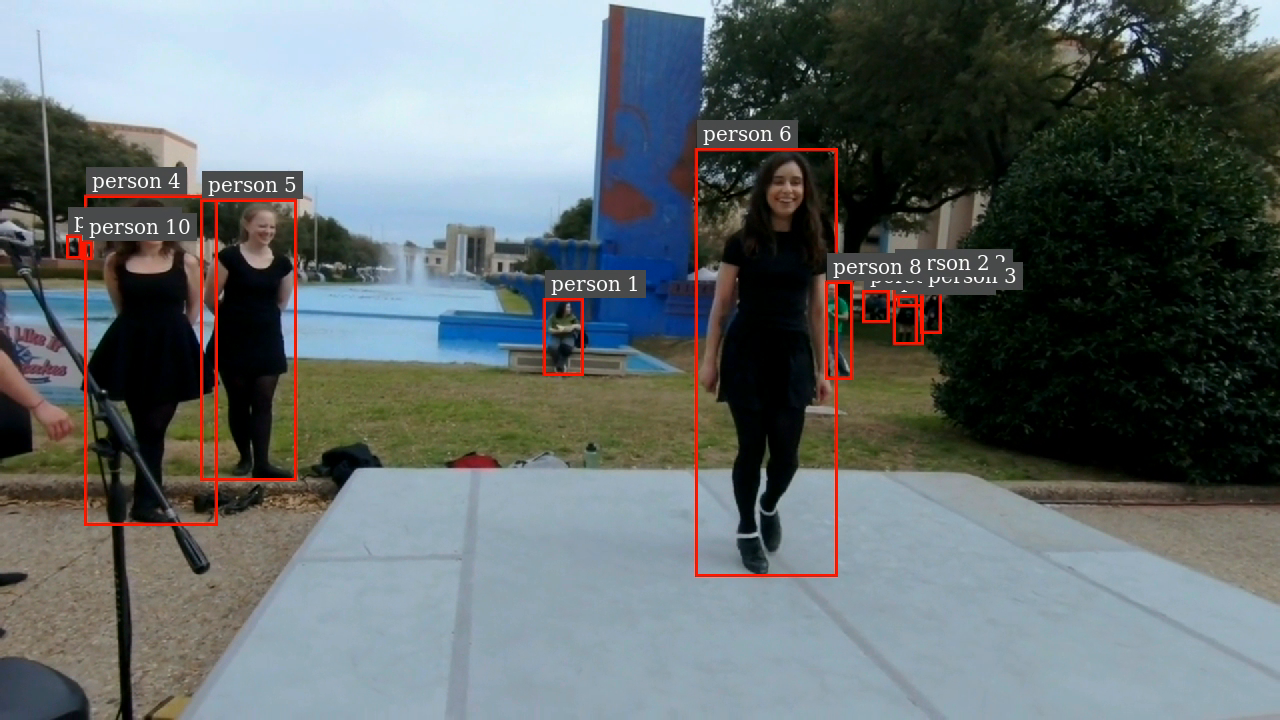

t = 5s


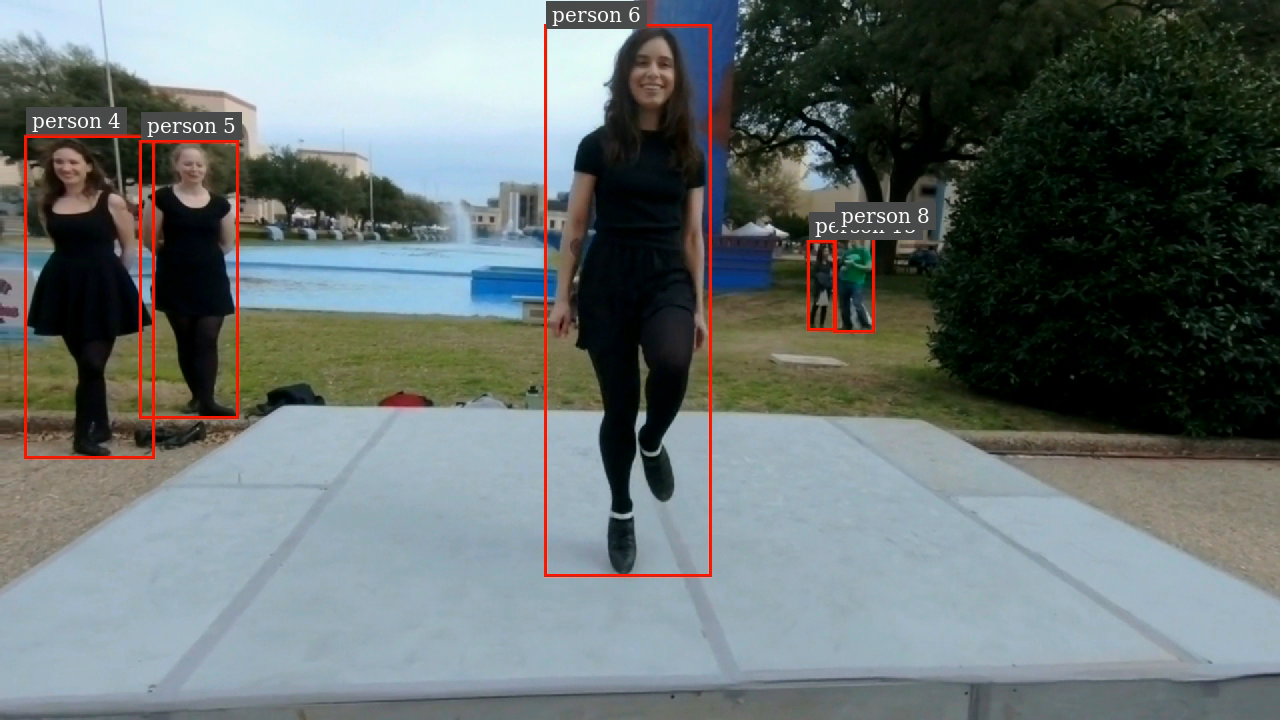

t = 8s


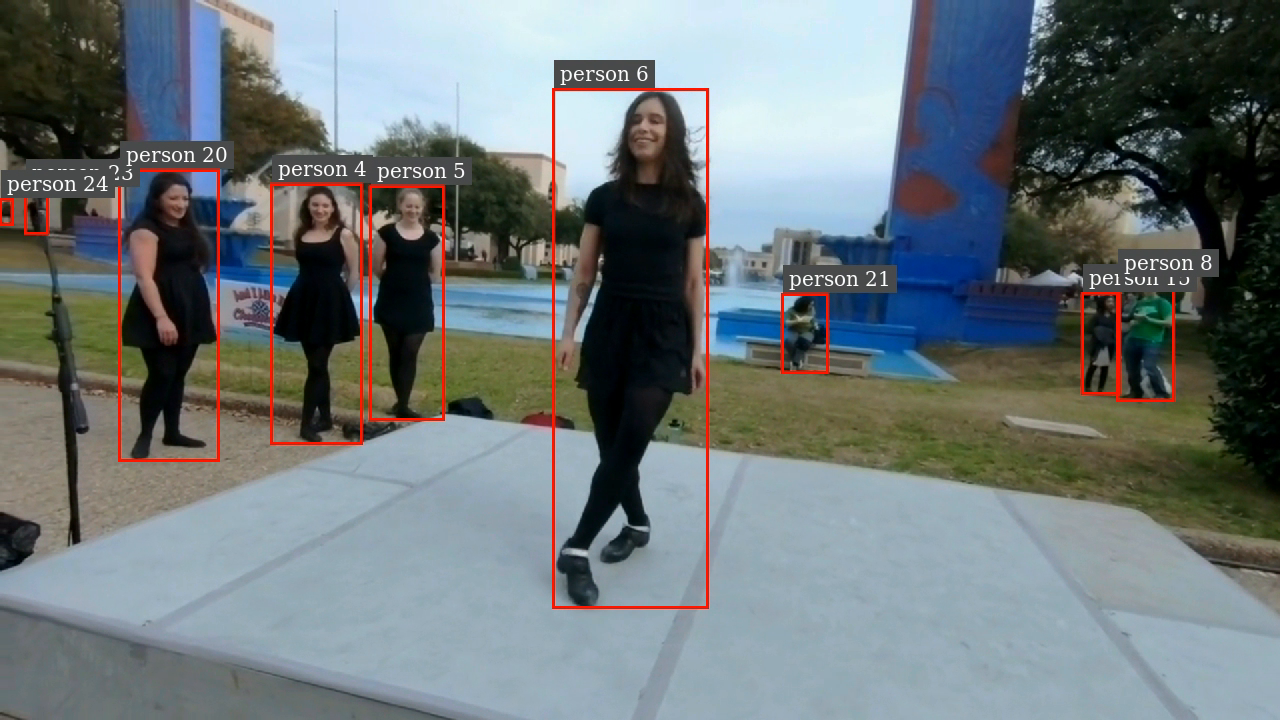

In [16]:
from IPython.display import Image, display

for t in (2, 5, 8):
    dex(f'ffmpeg -y -ss {t} -i /opt/storage/output/dance_tracked.mp4 -frames:v 1 '
        f'/opt/storage/output/frame_{t}s.png 2>/dev/null', show=False)

for t in (2, 5, 8):
    p = f'{HOST_MODELS}/output/frame_{t}s.png'
    print(f't = {t}s')
    display(Image(filename=p))

## Step 6 - Track-ID persistence (caveat for later phases)

The IDs are drawn per frame and look stable across the clip, but the ReID meta-buffer
warnings mean re-association can occasionally reassign an ID. For "who finished the
sequence first" (Phases 4-5) we need **per-frame (frame, track_id, bbox)** data, not just
pixels. Two ways to get it, to decide in Phase 4:

1. **Kafka metadata** - add a `[sink1] type=6` broker sink (topic `mdx-raw`) to this config;
   the same detections/IDs then stream as JSON we can parse.
2. **KITTI tracker dump** - have the tracker write per-frame label files we read directly.

If ID flips prove frequent, raising the ReID user-meta pool size (or the NvDCF re-assoc
settings) is the fix. We keep this config minimal for now and revisit when Phase 4 fixes
the fusion method.

## Summary

**Result.** `~/Documents/video_tracked/dance_tracked_alerts.mp4` - 1280x720, ~11 s, 330
frames, with bounding boxes and persistent `person N` track IDs.

**Changes made along the way (this session):**
- Copied `dance.mp4` into the shared mount and produced an audio-stripped `dance_clean.mp4`.
- Ensured the `x264enc` software encoder is installed (H100 has no NVENC).
- Created a static-source `deepstream-app` config to bypass the stalled REST/`nvmultiurisrcbin`
  path, reusing the profile's RT-DETR detector + NvDCF accuracy tracker.
- (Reverted) Exploratory edits to the live `run_config-api-rtdetr-protobuf.txt` were rolled
  back - they targeted the broken REST path and are not needed by this bypass.

**Persisted to the blueprint (for commit):**
- **New file** `deploy/docker/developer-profiles/dev-profile-alerts/deepstream/configs/ds_track_bypass.txt`
  - a documented, reusable offline single-file tracking config for `deepstream-app`. It
  records the H100 `enc-type=1` requirement and the reason the static-source path is used.

**Not persisted (runtime/vendor):** the `x264enc` install (image-level) and the
REST/`nvmultiurisrcbin` stall itself (under review with NVIDIA).